# AAL Sales Analysis - Q4 2020
## Objective
Analyze Australian Apparel Ltd (AAL) sales data for Q4 2020 to identify high-revenue states and develop intervention strategies for underperforming regions.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# Styling and display options
sns.set_style("darkgrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Data Wrangling
### 1.1 Load and Validate

In [7]:
import os

# Path to CSV (relative to notebook location)
filepath = os.path.join('../data', 'AusApparalSales4thQrt2020.csv')
if not os.path.exists(filepath):
    raise FileNotFoundError(f'File not found: {filepath}')

df = pd.read_csv(filepath)

print('Shape:', df.shape)
print('Info:')
df.info()

df.head()

if df.empty:
    raise ValueError('Loaded DataFrame is empty — check the source CSV or path.')

Shape: (7560, 6)
Info:
<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [11]:
# Inspect missing / present values
na_counts = df.isna().sum()
print('Missing values per column:')
print(na_counts)

# Show a quick boolean mask (first rows) to inspect not-null entries
print()
print('Not-null entries (first 5 rows):')
df.notna().head()

Missing values per column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Not-null entries (first 5 rows):


,Date,Time,State,Group,Unit,Sales
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,True,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True


### 1.2 Data Cleaning and Aggregation

### 1.2.1 Data Cleaning Strategy

**Finding:** No null values detected across all 7,560 rows and 6 columns.

**Decision:** No data cleaning required.

**Justification:** 
- The dataset represents aggregated transaction summaries at (Date, Time, State, Group) grain
- Each row is a complete observation with valid Units and Sales values
- No missing combinations or invalid entries detected
- Proceeding directly to aggregation and analysis


### 1.2.2 Data Aggregation Strategy
create multiple dimensional views to support exploration and visualization.

- Keep `df_daily` as the canonical daily-grain table (Date, Time, State, Group, Unit, Sales).
- Build focused rollups for time and dimensional analysis: week/time, state/group, group/state, daily, weekly, monthly, quarterly.
- Each rollup will be reset-indexed and surfaced with shape and a sample for quick inspection.

In [ ]:
# Build canonical daily-grain and multiple aggregation views for analysis
required_cols = ['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns for aggregation: {missing}')

# df_daily: daily-grain (one row per Date, Time, State, Group)
df_daily = df.groupby(['Date', 'Time', 'State', 'Group'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
df_daily.reset_index(drop=True, inplace=True)
# Ensure Date is datetime for period-based rollups
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
try:
    df_daily['Week'] = df_daily['Date'].dt.isocalendar().week
except Exception:
    df_daily['Week'] = df_daily['Date'].dt.week
df_daily['Month'] = df_daily['Date'].dt.month
df_daily['Quarter'] = df_daily['Date'].dt.quarter

# 1) Week-Time rollup
agg_time_week = df_daily.groupby(['Week', 'Time'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_time_week: {agg_time_week.shape}')
print(agg_time_week.head())

# 2) State-Group rollup
agg_state_group = df_daily.groupby(['State', 'Group'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_state_group: {agg_state_group.shape}')
print(agg_state_group.head())

# 3) Group-State rollup
agg_group_state = df_daily.groupby(['Group', 'State'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_group_state: {agg_group_state.shape}')
print(agg_group_state.head())

# 4) Daily totals
agg_daily = df_daily.groupby(['Date'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_daily: {agg_daily.shape}')
print(agg_daily.head())

# 5) Weekly totals
agg_weekly = df_daily.groupby(['Week'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_weekly: {agg_weekly.shape}')
print(agg_weekly.head())

# 6) Monthly totals
agg_monthly = df_daily.groupby(['Month'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_monthly: {agg_monthly.shape}')
print(agg_monthly.head())

# 7) Quarterly totals
agg_quarterly = df_daily.groupby(['Quarter'], as_index=False).agg({'Unit': 'sum', 'Sales': 'sum'})
print(f'agg_quarterly: {agg_quarterly.shape}')
print(agg_quarterly.head())

### Aggregation Strategy & GroupBy Insights

**Observation:** Each (Date, Time, State, Group) combination appears exactly once in the raw data.
This means we cannot collapse duplicates — instead, we strategically group by *subsets* of dimensions
to answer different business questions.

**Key insight:** GroupBy() is not for "merging duplicate rows" in this case, but for **dimensional analysis** —
selecting which dimensions to separate and which to collapse.

**Recommendation:** Store 7 aggregated views (one per analysis question) rather than recalculating
groupbys repeatedly in visualizations. This improves:
- Query clarity (each view has semantic meaning)
- Performance (aggregate once, use many times)
- Maintainability (single source of truth per analysis dimension).

### 1.3 Normalization

In [ ]:
# Placeholder for normalization logic — implement later
pass

## 2. Data Analysis
### 2.1 Descriptive Statistics
Skip mode on Sales and Units.
Why: Mode is only meaningful on discrete/categorical data. Sales and Units are continuous aggregates — each value likely appears 0-2 times across ~90 rows. Mode would be noise, not insight.

In [22]:
# Descriptive Statistics on Daily Aggregation
print("=== DAILY AGGREGATION STATISTICS ===")
daily_stats = agg_daily[['Unit', 'Sales']].describe()
print(daily_stats)

# Descriptive Statistics on Weekly Aggregation
print()
print("=== WEEKLY AGGREGATION STATISTICS ===")
weekly_stats = agg_weekly[['Unit', 'Sales']].describe()
print(weekly_stats)

# Additional: Variance and coefficient of variation
print("\n=== VARIANCE & STABILITY ===")
print("Daily - Coefficient of Variation (Sales):", (agg_daily['Sales'].std() / agg_daily['Sales'].mean()))
print("Weekly - Coefficient of Variation (Sales):", (agg_weekly['Sales'].std() / agg_weekly['Sales'].mean()))  

=== DAILY AGGREGATION STATISTICS ===
              Unit         Sales
count    90.000000  9.000000e+01
mean   1512.455556  3.781139e+06
std     249.954925  6.248873e+05
min    1090.000000  2.725000e+06
25%    1234.750000  3.086875e+06
50%    1519.500000  3.798750e+06
75%    1771.500000  4.428750e+06
max    1906.000000  4.765000e+06

=== WEEKLY AGGREGATION STATISTICS ===
               Unit         Sales
count     14.000000  1.400000e+01
mean    9722.928571  2.430732e+07
std     2357.345099  5.893363e+06
min     5517.000000  1.379250e+07
25%     8451.000000  2.112750e+07
50%     9689.500000  2.422375e+07
75%    11587.000000  2.896750e+07
max    12708.000000  3.177000e+07

=== VARIANCE & STABILITY ===
Daily - Coefficient of Variation (Sales): 0.16526431048339343
Weekly - Coefficient of Variation (Sales): 0.24245216675865


### 2.2 Highest and Lowest Sales

In [23]:
# Highest/Lowest Groups (Overall)
print("=== GROUP PERFORMANCE (OVERALL) ===")
print("Highest Sales Group:")
print(agg_state_group.groupby('Group')['Sales'].sum().idxmax(), "—", agg_state_group.groupby('Group')['Sales'].sum().max())
print("\nLowest Sales Group:")
print(agg_state_group.groupby('Group')['Sales'].sum().idxmin(), "—", agg_state_group.groupby('Group')['Sales'].sum().min())

# Highest/Lowest Groups by State
print("\n=== GROUP PERFORMANCE (BY STATE) ===")
for state in sorted(agg_state_group['State'].unique()):
    state_data = agg_state_group[agg_state_group['State'] == state]
    print(f"\n{state}:")
    print(f"  Highest: {state_data.loc[state_data['Sales'].idxmax(), 'Group']} ({state_data['Sales'].max()})")
    print(f"  Lowest: {state_data.loc[state_data['Sales'].idxmin(), 'Group']} ({state_data['Sales'].min()})")

=== GROUP PERFORMANCE (OVERALL) ===
Highest Sales Group:
 Men — 85750000

Lowest Sales Group:
 Seniors — 84037500

=== GROUP PERFORMANCE (BY STATE) ===

 NSW:
  Highest:  Women (19172500)
  Lowest:  Seniors (18187500)

 NT:
  Highest:  Men (5762500)
  Lowest:  Seniors (5465000)

 QLD:
  Highest:  Kids (8510000)
  Lowest:  Seniors (8190000)

 SA:
  Highest:  Women (14970000)
  Lowest:  Kids (14515000)

 TAS:
  Highest:  Kids (5775000)
  Lowest:  Women (5577500)

 VIC:
  Highest:  Women (26482500)
  Lowest:  Seniors (26315000)

 WA:
  Highest:  Men (5752500)
  Lowest:  Women (5262500)


### 2.3 Time-Based Aggregations

In [24]:
# Weekly Summary
print("=== WEEKLY SUMMARY ===")
print(agg_weekly.sort_values('Week'))

# Monthly Summary
print("\n=== MONTHLY SUMMARY ===")
print(agg_monthly.sort_values('Month'))

# Quarterly Summary
print("\n=== QUARTERLY SUMMARY ===")
print(agg_quarterly.sort_values('Quarter'))

=== WEEKLY SUMMARY ===
    Week   Unit     Sales
0     40   6018  15045000
1     41  10801  27002500
2     42  10656  26640000
3     43  10726  26815000
4     44   8723  21807500
5     45   8346  20865000
6     46   8469  21172500
7     47   8445  21112500
8     48   8591  21477500
9     49  11849  29622500
10    50  12610  31525000
11    51  12662  31655000
12    52  12708  31770000
13    53   5517  13792500

=== MONTHLY SUMMARY ===
   Month   Unit      Sales
0     10  45716  114290000
1     11  36273   90682500
2     12  54132  135330000

=== QUARTERLY SUMMARY ===
   Quarter    Unit      Sales
0        4  136121  340302500


## 3. Data Visualization

### 3.1 State-wise Sales by Group

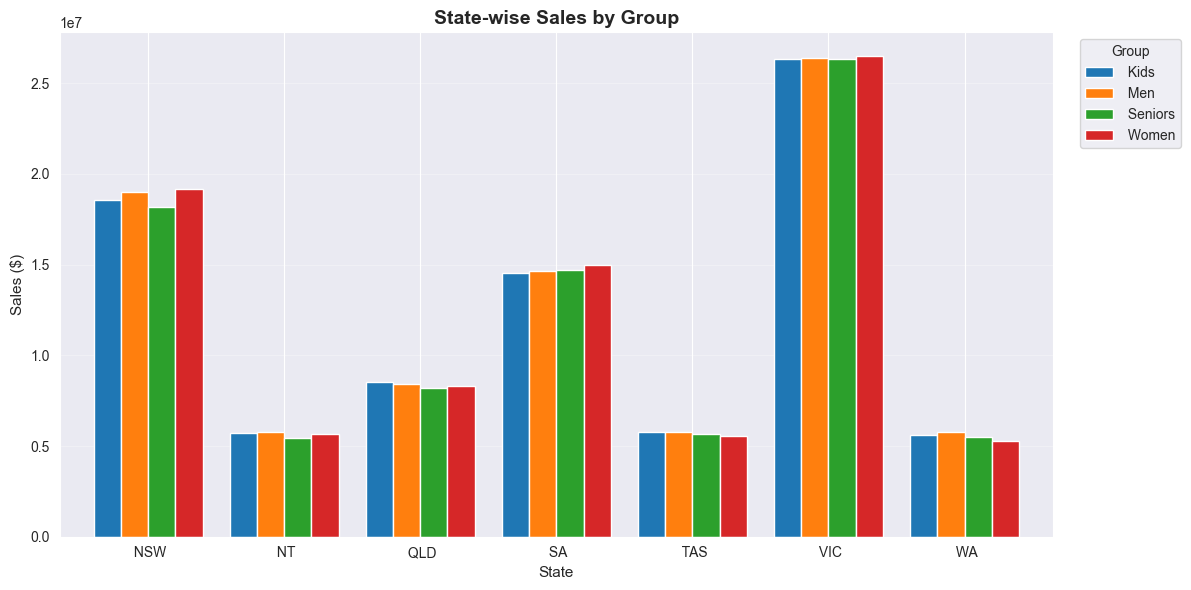

State-wise grouped bar chart created.


In [26]:
# State-wise Sales by Group: Grouped bar chart (States on X, Groups as bars)
fig, ax = plt.subplots(figsize=(12, 6))
pivot_state_group = agg_state_group.pivot(index='State', columns='Group', values='Sales')
pivot_state_group.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('State-wise Sales by Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=11)
ax.set_xlabel('State', fontsize=11)
ax.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('State-wise grouped bar chart created.')

### 3.2 Group-wise Sales by State

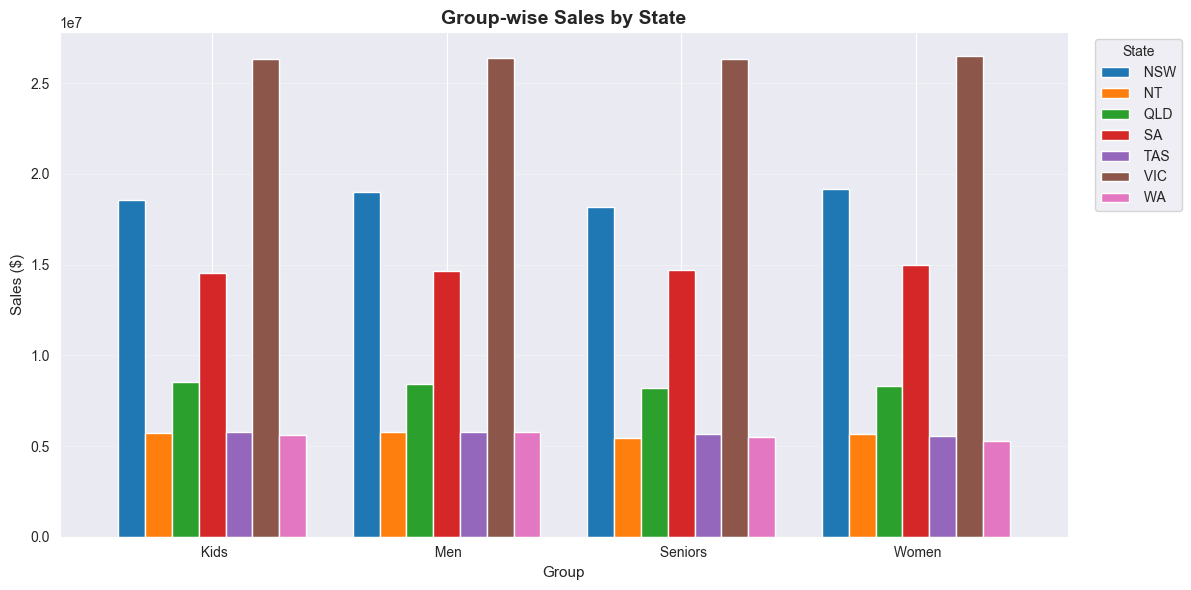

Group-wise grouped bar chart created.


In [27]:
# Group-wise Sales by State: Groups on X, States as grouped bars
fig, ax = plt.subplots(figsize=(12, 6))
# pivot so Groups are rows and States are columns (values = Sales)
pivot_group_state = agg_state_group.pivot(index='Group', columns='State', values='Sales')
pivot_group_state.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Group-wise Sales by State', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=11)
ax.set_xlabel('Group', fontsize=11)
ax.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('Group-wise grouped bar chart created.')

### 3.3 Time-of-Day Analysis (Peak/Off-Peak)

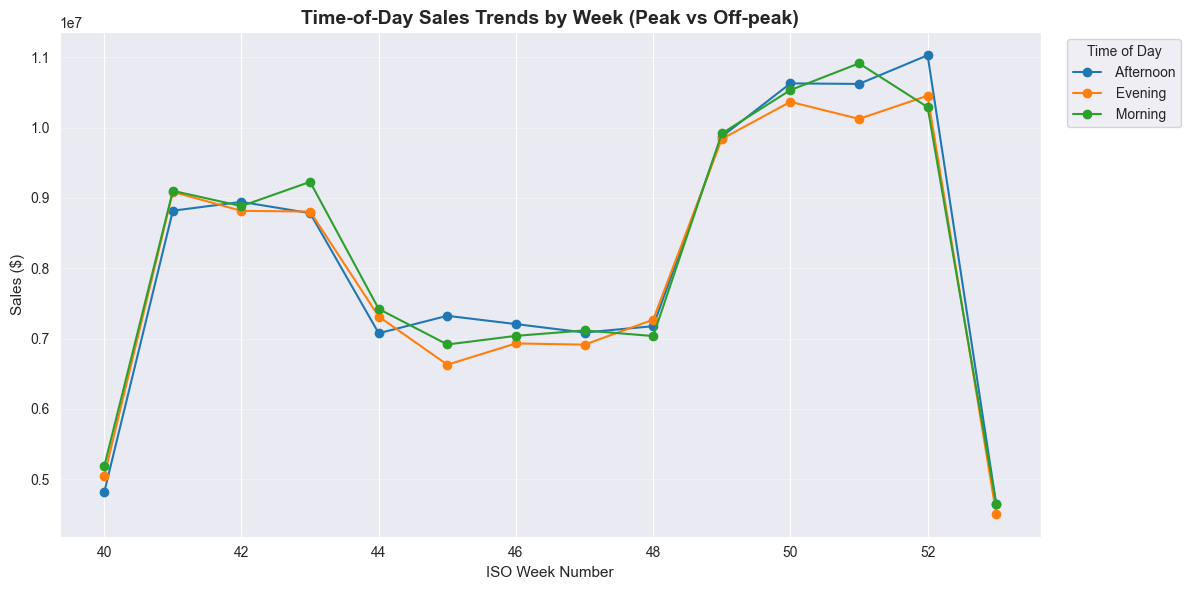

Time-of-day weekly trends plotted. Inspect peaks by comparing lines for Morning/Afternoon/Evening.


In [28]:
# Time-of-Day Analysis (Peak/Off-Peak) using agg_time_week
# Pivot to have Weeks as index and Time periods as columns
pivot_time_week = agg_time_week.pivot(index='Week', columns='Time', values='Sales').sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
pivot_time_week.plot(ax=ax, marker='o')
ax.set_title('Time-of-Day Sales Trends by Week (Peak vs Off-peak)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=11)
ax.set_xlabel('ISO Week Number', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Time of Day', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Time-of-day weekly trends plotted. Inspect peaks by comparing lines for Morning/Afternoon/Evening.')

### 3.4 Dashboard: Combined State/Group/Time Visualizations

This dashboard builds a 3x4 layout of exploratory charts: state-wise (daily/weekly/monthly/quarterly),
group-wise (daily/weekly/monthly/quarterly), and a time-of-day daily trend. The charts are generated
from in-memory aggregations and saved as `dashboard_section_3b.png`.

C:\Users\pbvw\AppData\Local\Temp\ipykernel_34376\3905089663.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Dashboard saved to: dashboard_section_3b.png


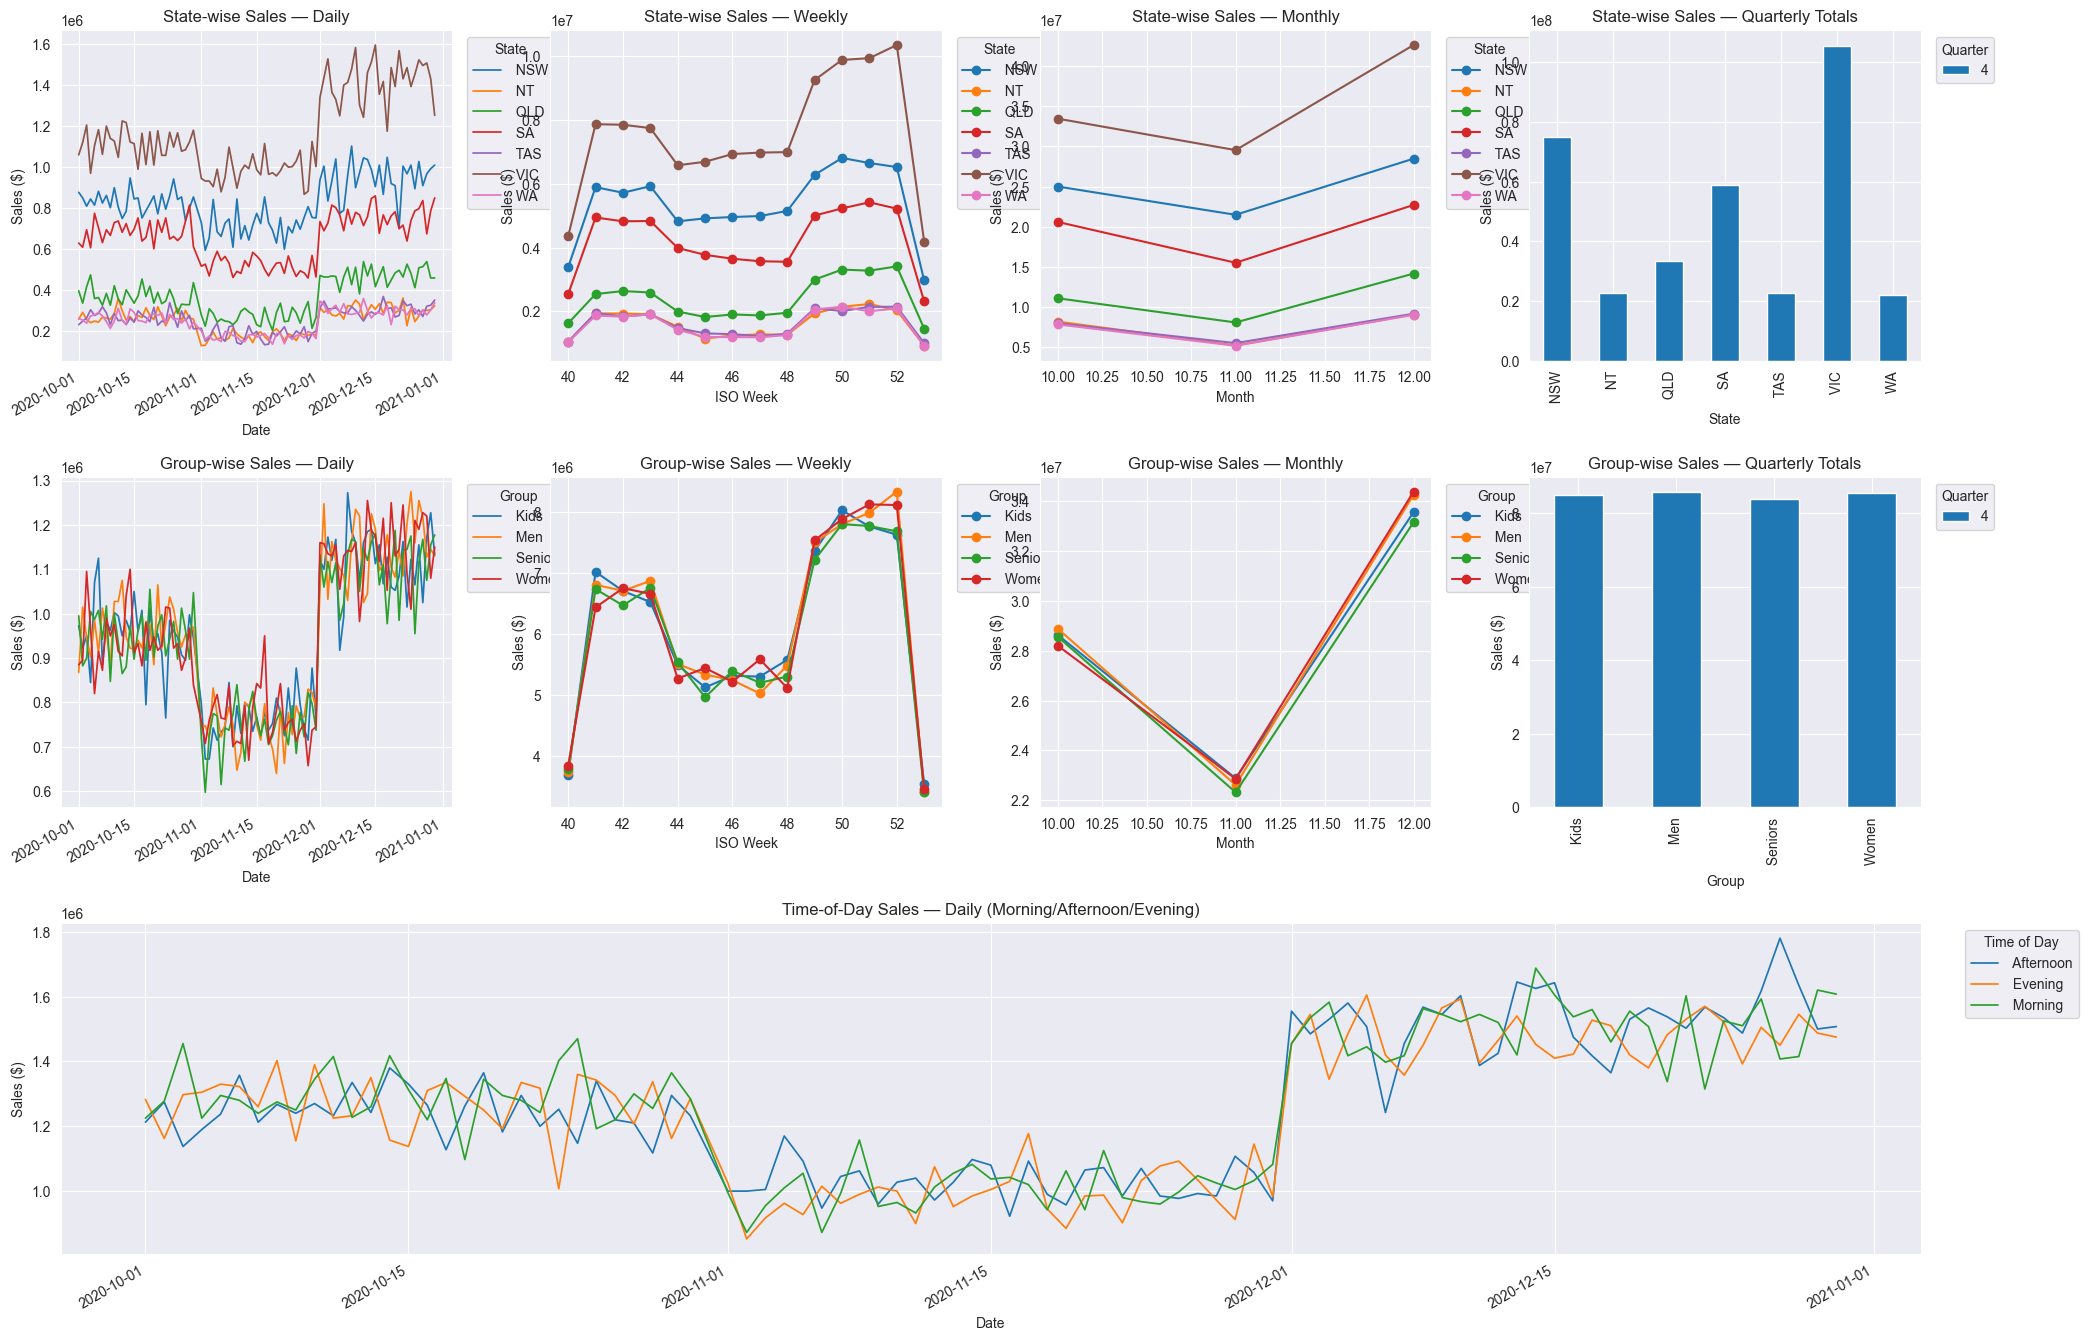

In [30]:
# Section 3.4: Build and save 3x4 dashboard (state/group/time)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Build in-memory aggregations (do not modify original data)
daily_by_state = df_daily.groupby(['Date', 'State'], as_index=False)['Sales'].sum().pivot(index='Date', columns='State', values='Sales')
daily_by_group = df_daily.groupby(['Date', 'Group'], as_index=False)['Sales'].sum().pivot(index='Date', columns='Group', values='Sales')
agg_daily_time = df_daily.groupby(['Date', 'Time'], as_index=False)['Sales'].sum().pivot(index='Date', columns='Time', values='Sales')

weekly_by_state = df_daily.groupby(['Week', 'State'], as_index=False)['Sales'].sum().pivot(index='Week', columns='State', values='Sales')
weekly_by_group = df_daily.groupby(['Week', 'Group'], as_index=False)['Sales'].sum().pivot(index='Week', columns='Group', values='Sales')

monthly_by_state = df_daily.groupby(['Month', 'State'], as_index=False)['Sales'].sum().pivot(index='Month', columns='State', values='Sales')
monthly_by_group = df_daily.groupby(['Month', 'Group'], as_index=False)['Sales'].sum().pivot(index='Month', columns='Group', values='Sales')

quarterly_by_state = df_daily.groupby(['Quarter', 'State'], as_index=False)['Sales'].sum().pivot(index='Quarter', columns='State', values='Sales')
quarterly_by_group = df_daily.groupby(['Quarter', 'Group'], as_index=False)['Sales'].sum().pivot(index='Quarter', columns='Group', values='Sales')

# Create figure with 3 rows x 4 cols (row3 spans all columns)
fig = plt.figure(constrained_layout=False, figsize=(24, 18))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.25)

# Row 1 axes (state-wise)
ax_s_daily = fig.add_subplot(gs[0, 0])
ax_s_weekly = fig.add_subplot(gs[0, 1])
ax_s_monthly = fig.add_subplot(gs[0, 2])
ax_s_quarter = fig.add_subplot(gs[0, 3])

# Row 2 axes (group-wise)
ax_g_daily = fig.add_subplot(gs[1, 0])
ax_g_weekly = fig.add_subplot(gs[1, 1])
ax_g_monthly = fig.add_subplot(gs[1, 2])
ax_g_quarter = fig.add_subplot(gs[1, 3])

# Row 3 axis (time-of-day) spans all columns
ax_time = fig.add_subplot(gs[2, :])

# Plot Row 1: State-wise
if not daily_by_state.empty:
    daily_by_state.plot(ax=ax_s_daily, linewidth=1.25)
ax_s_daily.set_title('State-wise Sales — Daily')
ax_s_daily.set_xlabel('Date')
ax_s_daily.set_ylabel('Sales ($)')
ax_s_daily.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')

if not weekly_by_state.empty:
    weekly_by_state.plot(ax=ax_s_weekly, linewidth=1.5, marker='o')
ax_s_weekly.set_title('State-wise Sales — Weekly')
ax_s_weekly.set_xlabel('ISO Week')
ax_s_weekly.set_ylabel('Sales ($)')
ax_s_weekly.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')

if not monthly_by_state.empty:
    monthly_by_state.plot(ax=ax_s_monthly, linewidth=1.5, marker='o')
ax_s_monthly.set_title('State-wise Sales — Monthly')
ax_s_monthly.set_xlabel('Month')
ax_s_monthly.set_ylabel('Sales ($)')
ax_s_monthly.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')

if not quarterly_by_state.empty:
    quarterly_by_state.T.plot(kind='bar', ax=ax_s_quarter)
ax_s_quarter.set_title('State-wise Sales — Quarterly Totals')
ax_s_quarter.set_xlabel('State')
ax_s_quarter.set_ylabel('Sales ($)')
ax_s_quarter.legend(title='Quarter', bbox_to_anchor=(1.02, 1), loc='upper left')

# Plot Row 2: Group-wise
if not daily_by_group.empty:
    daily_by_group.plot(ax=ax_g_daily, linewidth=1.25)
ax_g_daily.set_title('Group-wise Sales — Daily')
ax_g_daily.set_xlabel('Date')
ax_g_daily.set_ylabel('Sales ($)')
ax_g_daily.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

if not weekly_by_group.empty:
    weekly_by_group.plot(ax=ax_g_weekly, linewidth=1.5, marker='o')
ax_g_weekly.set_title('Group-wise Sales — Weekly')
ax_g_weekly.set_xlabel('ISO Week')
ax_g_weekly.set_ylabel('Sales ($)')
ax_g_weekly.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

if not monthly_by_group.empty:
    monthly_by_group.plot(ax=ax_g_monthly, linewidth=1.5, marker='o')
ax_g_monthly.set_title('Group-wise Sales — Monthly')
ax_g_monthly.set_xlabel('Month')
ax_g_monthly.set_ylabel('Sales ($)')
ax_g_monthly.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

if not quarterly_by_group.empty:
    quarterly_by_group.T.plot(kind='bar', ax=ax_g_quarter)
ax_g_quarter.set_title('Group-wise Sales — Quarterly Totals')
ax_g_quarter.set_xlabel('Group')
ax_g_quarter.set_ylabel('Sales ($)')
ax_g_quarter.legend(title='Quarter', bbox_to_anchor=(1.02, 1), loc='upper left')

# Row 3: Time-of-day daily trends
if not agg_daily_time.empty:
    agg_daily_time.plot(ax=ax_time, linewidth=1.25)
ax_time.set_title('Time-of-Day Sales — Daily (Morning/Afternoon/Evening)')
ax_time.set_xlabel('Date')
ax_time.set_ylabel('Sales ($)')
ax_time.legend(title='Time of Day', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
# Save figure to file in the scripts folder
out_file = 'dashboard_section_3b.png'
fig.savefig(out_file, dpi=150, bbox_inches='tight')
print(f'Dashboard saved to: {out_file}')

## 4. Insights and Recommendations

[Placeholder for business insights]